Adding physical features, and using the difference instead of the raw values. using XGBoost (don't know why)

# Load Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from utils.data_loader import load_parquet, load_csv

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay', '|avg B|', 'F10.7 (LASP)']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())


✅ Successfully loaded data with shape: (3157920, 4)
                 time  orbital_decay   |avg B|  F10.7 (LASP)
0 2023-01-01 00:00:00        16.6730  5.630000         153.0
1 2023-01-01 00:00:20        16.6730  5.633333         153.0
2 2023-01-01 00:00:40        16.6735  5.636667         153.0
3 2023-01-01 00:01:00        16.6740  5.640000         153.0
4 2023-01-01 00:01:20        16.6740  5.633333         153.0


# 1. Select a subset

In [2]:
from utils.plot_loader import create_subset
# =========================== Input ===================================
start_date = '2024-04-26 00:00:00'
end_date = '2024-05-01 00:00:00'
# =====================================================================

subset = create_subset(GFOC_data, start_date, end_date)
time = subset['time'].values
# make 'time' the index
subset.set_index('time', inplace=True)

# 2. Prepare Data

use difference instead of raw values for orbital decay

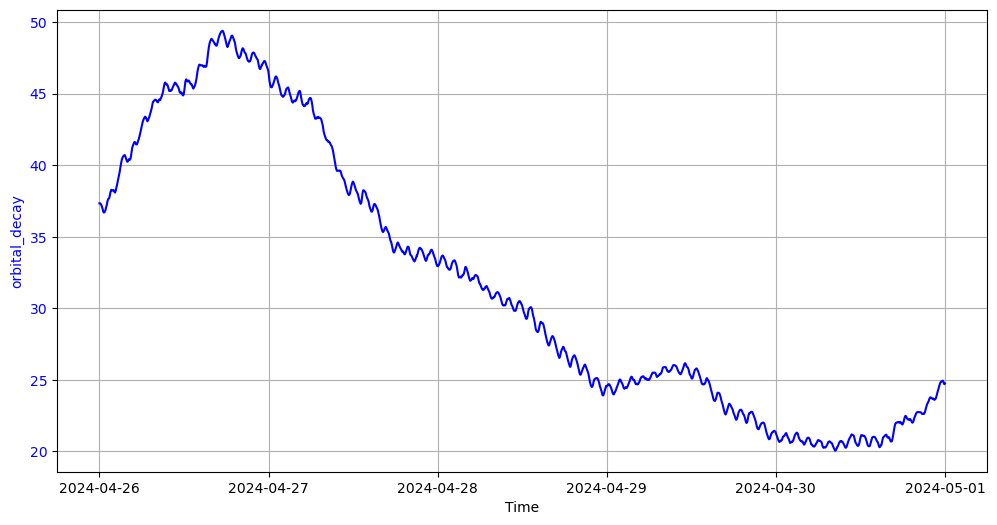

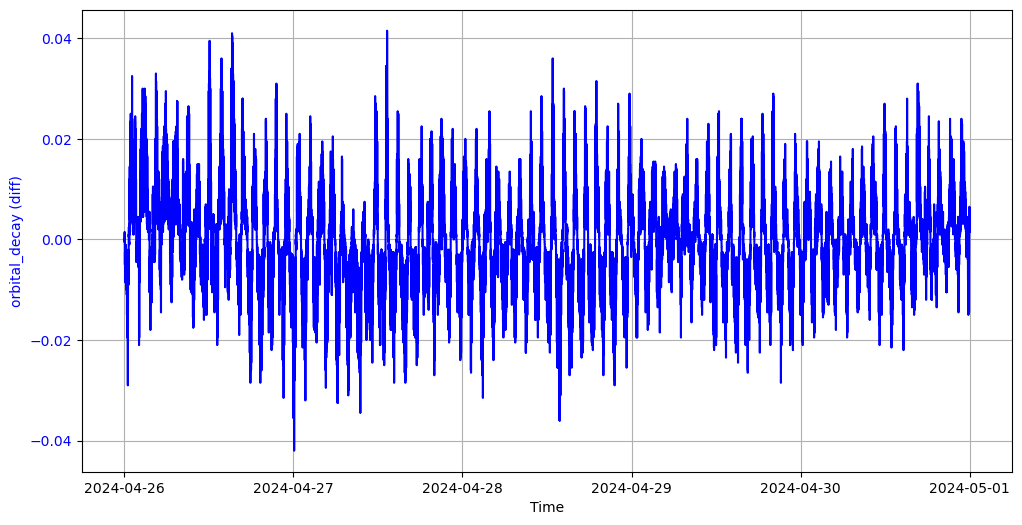

In [3]:
y0 = subset[['orbital_decay']].copy()
y = y0.diff().fillna(0.0)  # Use difference to make the series stationary

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(time, y0, label='orbital_decay (diff)', color='blue')
ax.set_xlabel('Time')
ax.set_ylabel('orbital_decay', color='blue')
ax.tick_params(axis='y', labelcolor='blue')
ax.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(time, y, label='orbital_decay (diff)', color='blue')
ax.set_xlabel('Time')
ax.set_ylabel('orbital_decay (diff)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')
ax.grid(True)
plt.show()

In [4]:
def make_lags(ts, lags, lead_time=1, step_size=1):
    return pd.concat(
        {
            f'y_lag_{i}': ts.shift(i)
            for i in range(lead_time, lags * step_size + lead_time, step_size)
        },
        axis=1)

def make_multistep_target(ts, steps):
    return pd.concat(
        {f'y_step_{i + 1}': ts.shift(-i)
         for i in range(steps)},
        axis=1)

y = y0.diff().fillna(0.0)

# Create lag features for the main target
X_lags = make_lags(y, lags=20, step_size=15).fillna(0.0)

# Add physical (instantaneous) drivers
X_physical = subset[['|avg B|', 'F10.7 (LASP)']]

# Combine them into one feature matrix
X = pd.concat([X_lags, X_physical], axis=1)

# n hour forecast (20 second intervals)
n = 1
y = make_multistep_target(y, steps=n * 3 * 60).dropna()

# Shifting has created indexes that don't match. Only keep times for
# which we have both targets and features.
y, X = y.align(X, join='inner', axis=0)

X.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in X.columns]
y.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in y.columns]

In [5]:
# def make_lags(df, lag_config, lead_time=1):
#     """
#     Create lag features for multiple columns with customizable lag depth and step size per feature.

#     Parameters
#     ----------
#     df : pd.DataFrame
#         Input data containing the columns to lag.
#     lag_config : dict
#         Dictionary specifying the lag depth and step size per column.
#         Example:
#             lag_config = {
#                 'orbital_decay': {'lags': 10, 'step': 20},
#                 '|avg B|': {'lags': 3, 'step': 10},
#                 'F10.7 (LASP)': {'lags': 5, 'step': 60}
#             }
#     lead_time : int, default=1
#         Minimum shift before the first lag (useful for forecasting ahead).

#     Returns
#     -------
#     pd.DataFrame
#         DataFrame containing all generated lagged features.
#     """
#     out = {}

#     for col, params in lag_config.items():
#         n_lags = params.get('lags', 1)
#         step = params.get('step', 1)

#         for i in range(lead_time, n_lags * step + lead_time, step):
#             out[f"{col}_lag_{i}"] = df[col].shift(i)

#     return pd.DataFrame(out)


# def make_multistep_target(ts, steps):
#     return pd.concat(
#         {f'y_step_{i + 1}': ts.shift(-i)
#          for i in range(steps)},
#         axis=1)


# lag_config = {
#     'orbital_decay': {'lags': 10, 'step': 15},   # every 20 samples
#     '|avg B|': {'lags': 3, 'step': 10},          # every 20 samples
#     'F10.7 (LASP)': {'lags': 5, 'step': 5}      # every 5 samples
# }

# X = make_lags(subset, lag_config).fillna(0.0)

# # n hour forecast (20 second intervals)
# n = 1
# y = make_multistep_target(subset[['orbital_decay']].copy(), steps=n * 3 * 60).dropna()

# # Shifting has created indexes that don't match. Only keep times for
# # which we have both targets and features.
# y, X = y.align(X, join='inner', axis=0)

# X.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in X.columns]
# y.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in y.columns]

# 3. Multioutput Model

In [6]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train-test split (chronologically)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# model = LinearRegression()
model = MultiOutputRegressor(XGBRegressor())
model.fit(X_train, y_train)

y_fit = pd.DataFrame(model.predict(X_train), index=X_train.index, columns=y.columns)
y_pred = pd.DataFrame(model.predict(X_test), index=X_test.index, columns=y.columns)

/home/dschwarz/anaconda3/envs/mt_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


### Sanity check

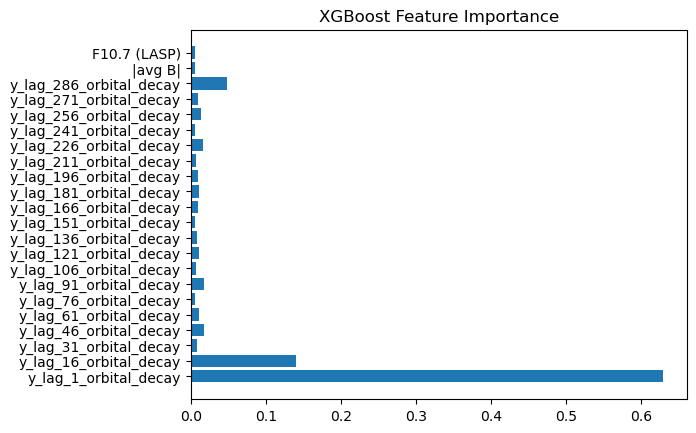

In [7]:
import matplotlib.pyplot as plt

feature_importance = model.estimators_[0].feature_importances_
plt.barh(X.columns, feature_importance)
plt.title("XGBoost Feature Importance")
plt.show()

Save model

In [8]:
# model_10_20 = model

## Results

In [9]:
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

simplefilter("ignore")

# Set Matplotlib defaults
plt.style.use("default")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'


def plot_multistep(y, every=1, ax=None, palette_kwargs=None):
    palette_kwargs_ = dict(palette='husl', n_colors=16, desat=None)
    if palette_kwargs is not None:
        palette_kwargs_.update(palette_kwargs)
    palette = sns.color_palette(**palette_kwargs_)
    if ax is None:
        fig, ax = plt.subplots()
    ax.set_prop_cycle(plt.cycler('color', palette))
    for date, preds in y[::every].iterrows():
        preds.index = pd.period_range(start=date, periods=len(preds), freq='20S')
        preds.plot(ax=ax, alpha=0.5)
    return ax

## Results

In [10]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

train_rmse = mean_squared_error(y_train, y_fit)
test_rmse = mean_squared_error(y_test, y_pred)
print((f"Train RMSE: {train_rmse:.3}\n" f"Test RMSE: {test_rmse:.3}"))
train_r2 = r2_score(y_train, y_fit)
test_r2 = r2_score(y_test, y_pred)
print((f"Train R2: {train_r2:.3}\n" f"Test R2: {test_r2:.3}"))

Train RMSE: 6.07e-06
Test RMSE: 2.54e-05
Train R2: 0.924
Test R2: 0.44


## Plot

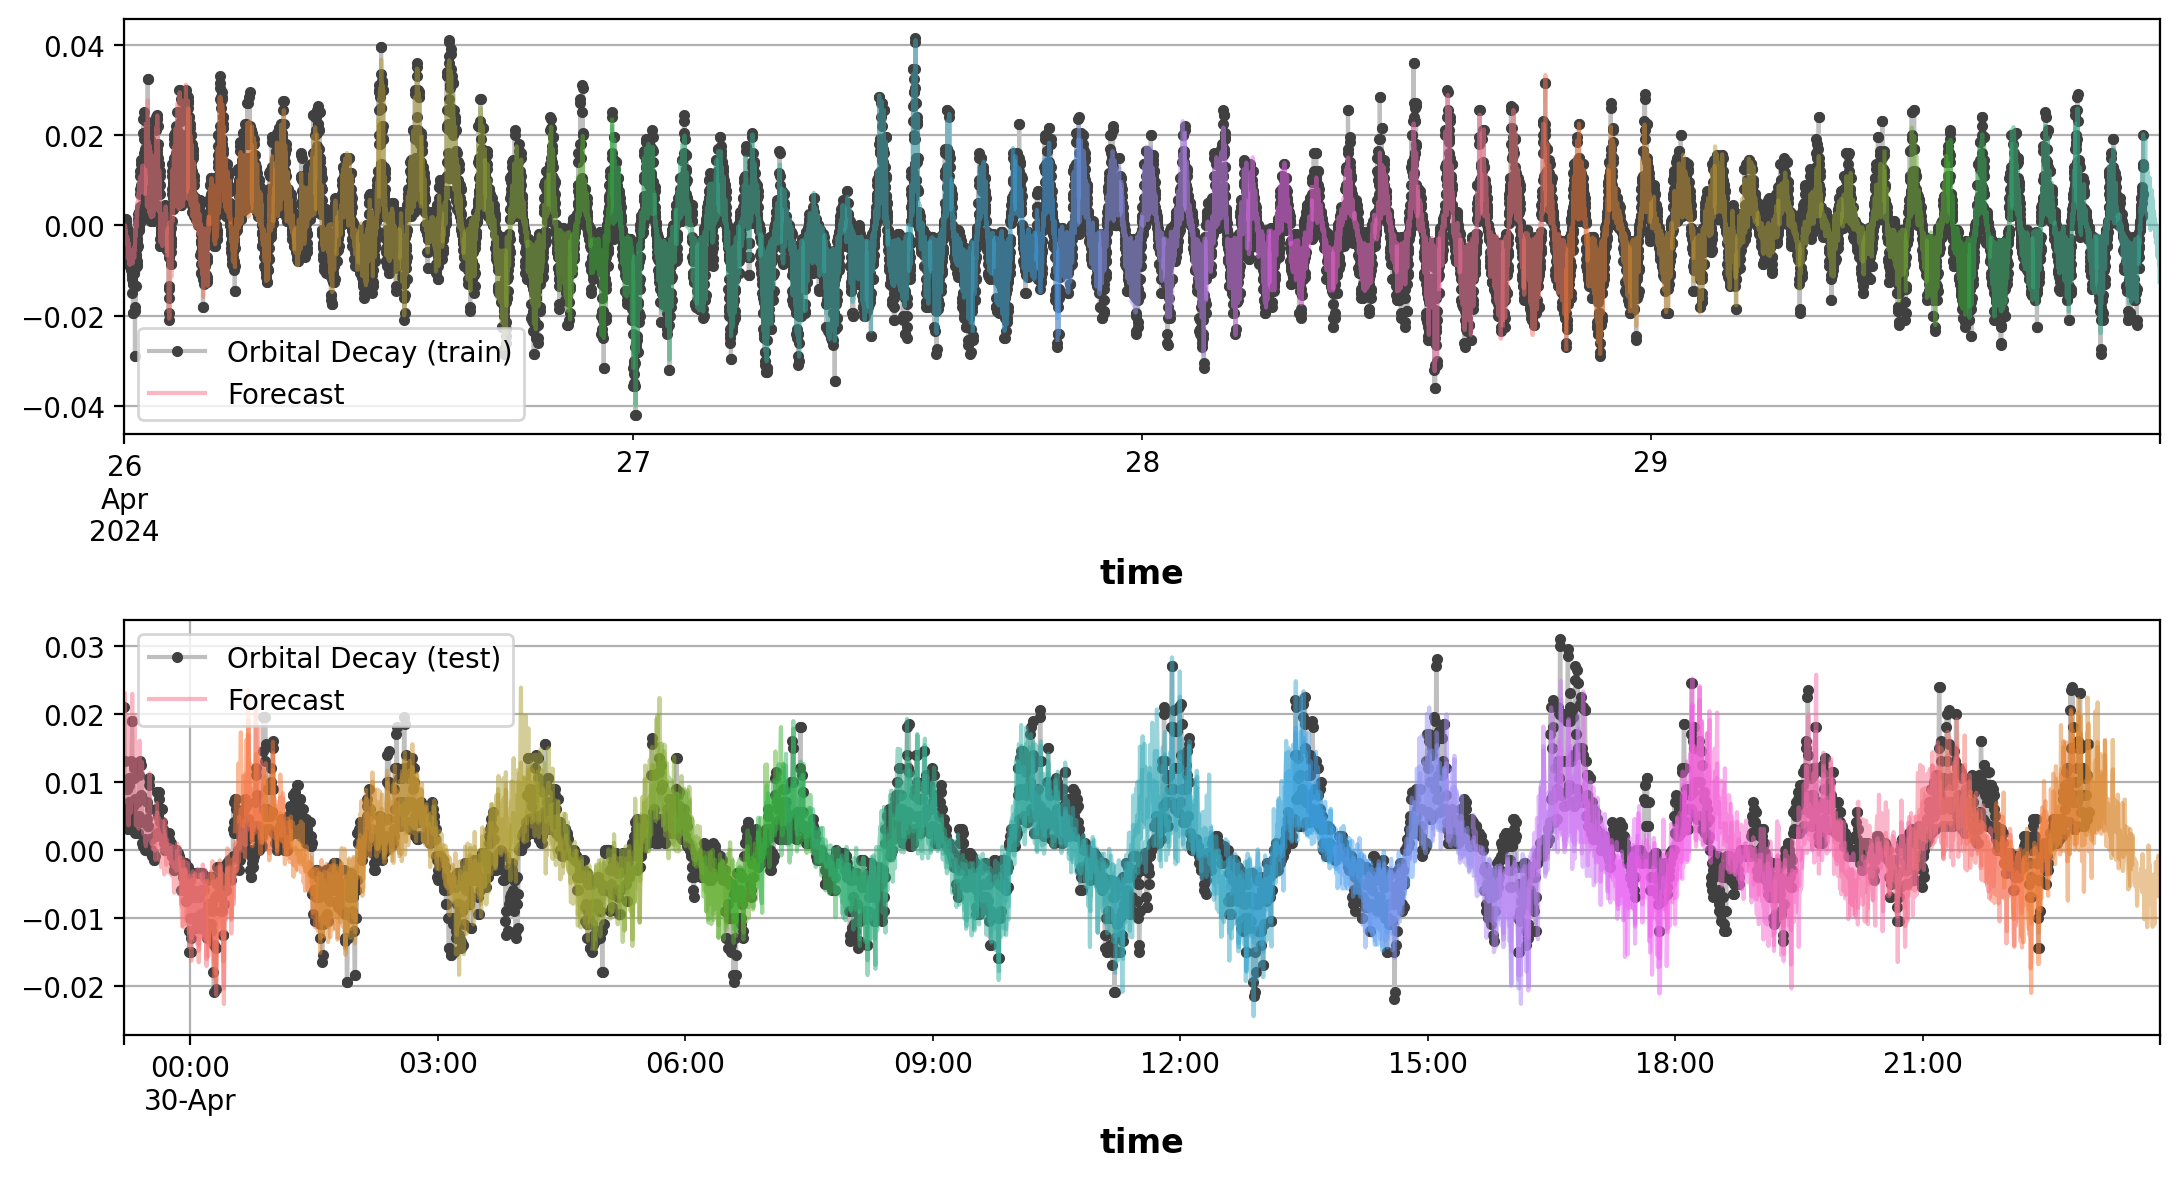

In [11]:

palette = dict(palette='husl', n_colors=64)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1 = y_train.iloc[:,[0]].plot(**plot_params, ax=ax1)
ax1 = plot_multistep(y_fit, every=180, ax=ax1, palette_kwargs=palette)
_ = ax1.legend(['Orbital Decay (train)', 'Forecast'])
ax1.grid(True)

ax2 = y_test.iloc[:,[0]].plot(**plot_params, ax=ax2)
ax2 = plot_multistep(y_pred, every=60, ax=ax2, palette_kwargs=palette)
_ = ax2.legend(['Orbital Decay (test)', 'Forecast'])
ax2.grid(True)

## Get back to orbital decay

In [12]:
import numpy as np

y0 = subset[['orbital_decay']].copy()
y0 = make_multistep_target(y0, steps=n * 3 * 60).dropna()
y0 = y0.iloc[:, 0]

y0_fit = y0.iloc[:len(y_fit)]

y_fit_sum = np.cumsum(y_fit[::60], axis=1)
y_fit_abs = y_fit_sum + y0_fit[::60].values.reshape(-1, 1)

In [13]:
y0_pred = y0.iloc[-len(y_pred):]

y_pred_sum = np.cumsum(y_pred[::30], axis=1)
y_pred_abs = y_pred_sum + y0_pred[::30].values.reshape(-1, 1)

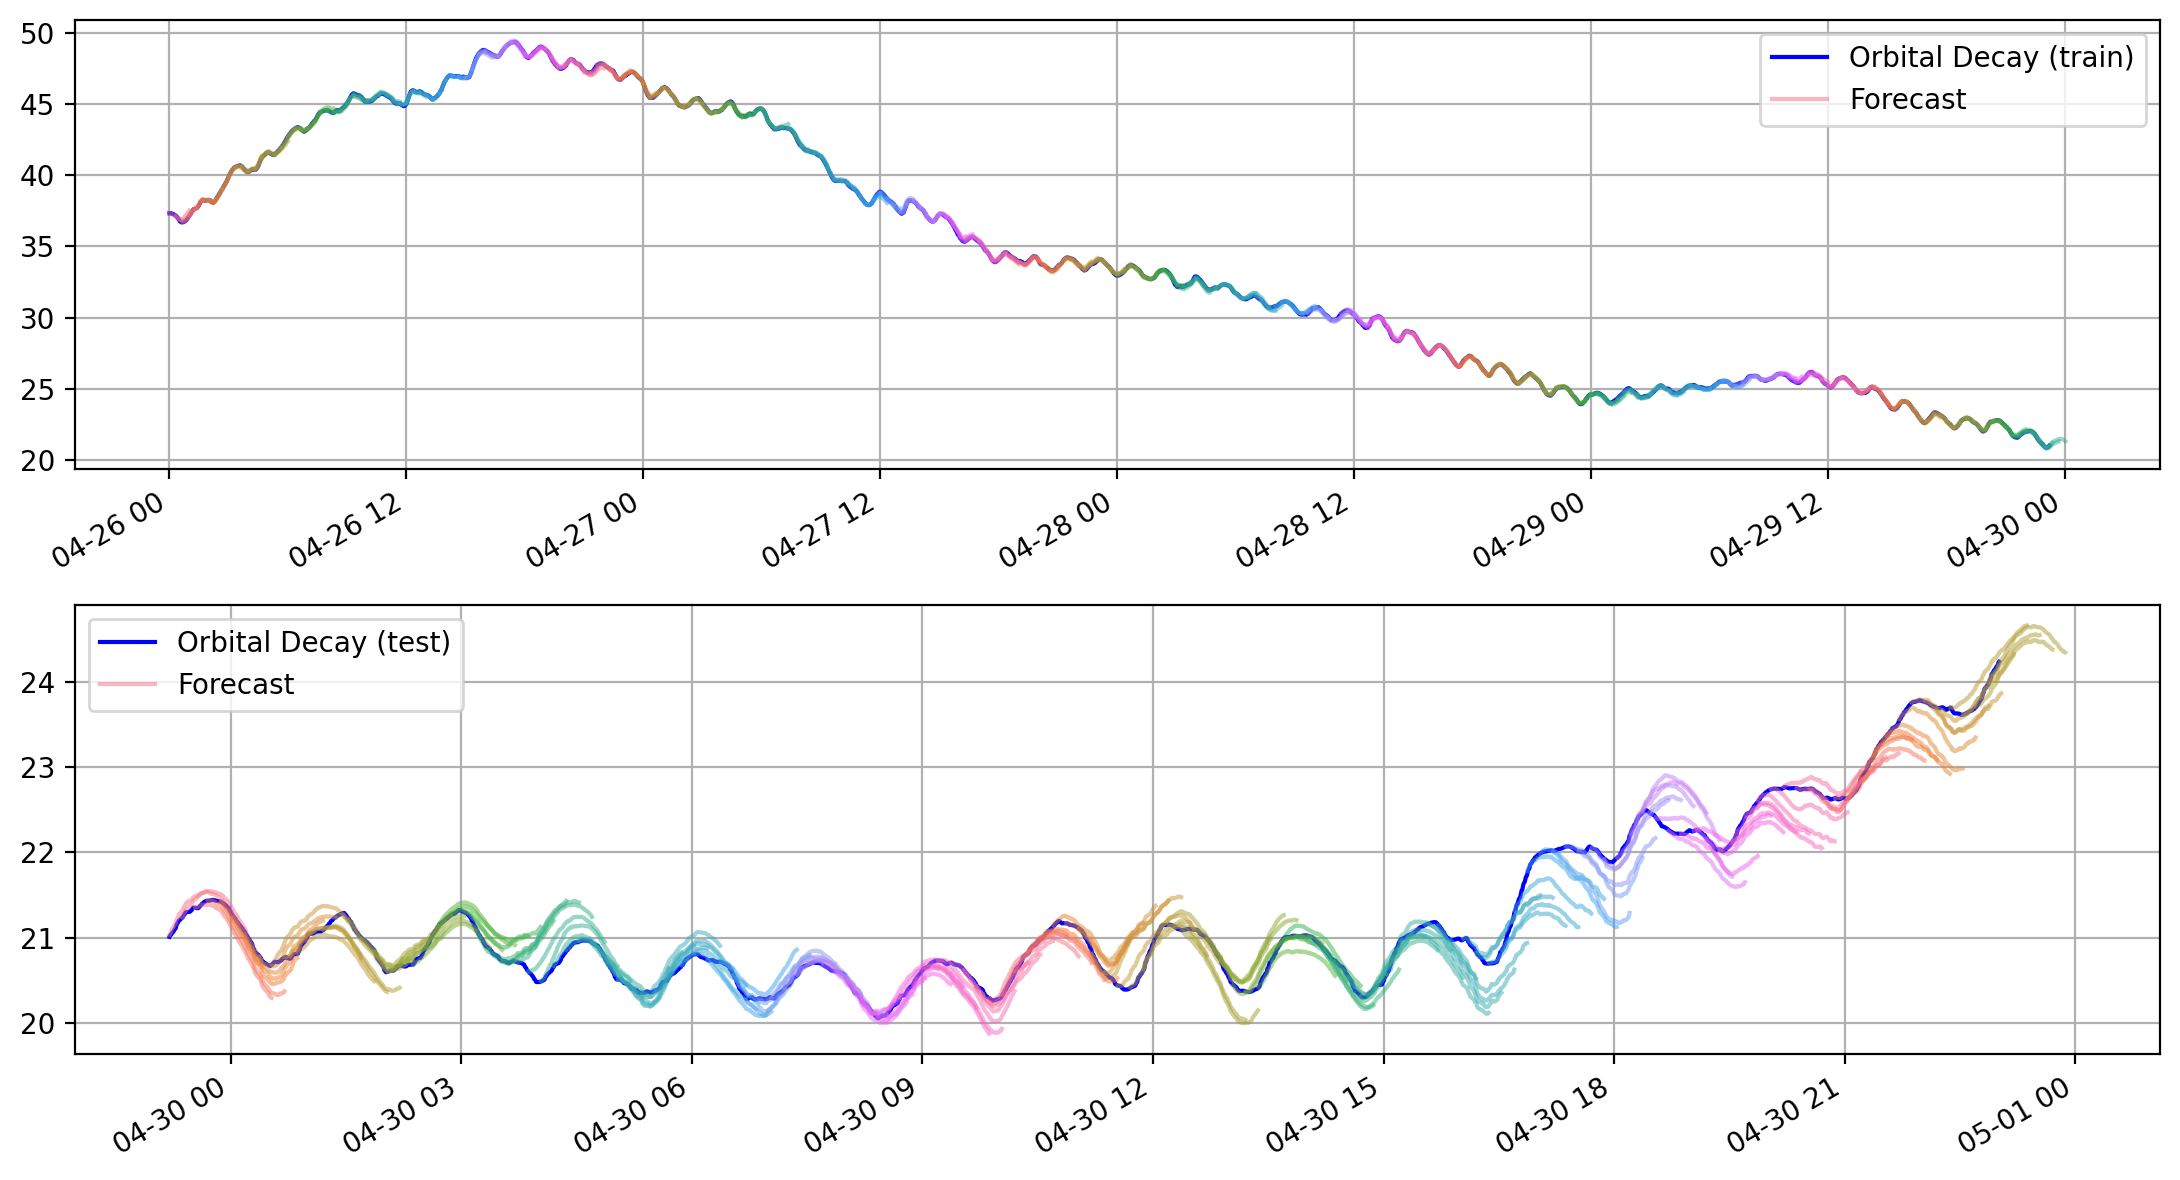

In [14]:

palette = dict(palette='husl', n_colors=64)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1.plot(y0_fit, color='blue')
ax1 = plot_multistep(y_fit_abs, ax=ax1, palette_kwargs=palette)
_ = ax1.legend(['Orbital Decay (train)', 'Forecast'])
ax1.grid(True)

ax2.plot(y0_pred, color='blue')
ax2 = plot_multistep(y_pred_abs, ax=ax2, palette_kwargs=palette)
_ = ax2.legend(['Orbital Decay (test)', 'Forecast'])
ax2.grid(True)

## Summary

- works much better with difference, but still not great.